# **Document Parser?**

### 2025 도큐먼트 파서 비교! Synap DocuAnalyzer VS 업스테이지 Document Parse
https://www.youtube.com/watch?v=Zk3ipzTMe1g

# **upstage Document Parse**


#### upstage 화제의 Document Parse 개발하신 분들께 직접 물어보겠습니다! 
https://www.youtube.com/watch?v=wE42SIAWCmg

In [1]:
from dotenv import load_dotenv

# 환경변수 로드
load_dotenv()

True

### Upstage Document Parse API로 호출하기

In [3]:
# pip install -qU langchain-core langchain-upstage

import os
from langchain_upstage import UpstageDocumentParseLoader

file_path = "./data/[삼성전자]반기보고서_12.pdf"  # ex: ./document.pdf

loader = UpstageDocumentParseLoader(
    file_path,
    model="document-parse-250618",
    ocr="auto",
    coordinates=True,
    base64_encoding=["figure"],
)
pages = loader.load()  # or loader.lazy_load()
for page in pages:
    print(page)

page_content='<h1 id='0' style='font-size:20px'>사. 그 밖에 경영활동과 관련된 중요한 사항의 발생내용</h1><h1 id='1' style='font-size:18px'>( 1) 경영활동과 관련된 중요한 사항의 발생</h1><table id='2' style='font-size:16px'><thead><tr><td>연도</td><td>내용</td></tr></thead><tbody><tr><td rowspan="4">2021</td><td>'Neo QLED TV' 공개</td></tr><tr><td>전세계 반도체 업체 최초 전 사업장 '탄소/물/폐기물 저감' 인증</td></tr><tr><td>업계 최선단 14나노 EUV DDR5 D램 양산</td></tr><tr><td>미국 테일러市에 신규 파운드리 라인 투자 발표</td></tr><tr><td rowspan="4">2022</td><td>BESPOKE 인피니트 라인 공개</td></tr><tr><td>세계 최초 3나노 GAA 파운드리 양산</td></tr><tr><td>차세대 반도체 R&D단지 기공식</td></tr><tr><td>1Tb 8세대 V낸드 양산</td></tr><tr><td rowspan="5">2023</td><td>초고화소 기술 집약된 2억 화소 이미지센서 '아이소셀 HP2' 출시</td></tr><tr><td>업계 최선단 12나노급 D램 양산</td></tr><tr><td>'Galaxy Z 폴드5', 'Galaxy Z 플립5' 공개</td></tr><tr><td>현존 최대 용량 32Gb DDR5 D램 개발</td></tr><tr><td>생성형 AI '삼성 가우스' 공개</td></tr><tr><td rowspan="5">2024</td><td>'Galaxy S24 시리즈' 공개</td></tr><tr><td>업계 최초 '9세대 V낸드' 양산</td></tr><tr><td>'Galaxy Z 폴드6', 'Galaxy Z 플립6' 공개</td></tr><t

In [23]:
#pages[0].page_content를 html로 출력하기
pages[0].page_content

'<h1 id=\'0\' style=\'font-size:20px\'>사. 그 밖에 경영활동과 관련된 중요한 사항의 발생내용</h1><h1 id=\'1\' style=\'font-size:18px\'>( 1) 경영활동과 관련된 중요한 사항의 발생</h1><table id=\'2\' style=\'font-size:16px\'><thead><tr><td>연도</td><td>내용</td></tr></thead><tbody><tr><td rowspan="4">2021</td><td>\'Neo QLED TV\' 공개</td></tr><tr><td>전세계 반도체 업체 최초 전 사업장 \'탄소/물/폐기물 저감\' 인증</td></tr><tr><td>업계 최선단 14나노 EUV DDR5 D램 양산</td></tr><tr><td>미국 테일러市에 신규 파운드리 라인 투자 발표</td></tr><tr><td rowspan="4">2022</td><td>BESPOKE 인피니트 라인 공개</td></tr><tr><td>세계 최초 3나노 GAA 파운드리 양산</td></tr><tr><td>차세대 반도체 R&D단지 기공식</td></tr><tr><td>1Tb 8세대 V낸드 양산</td></tr><tr><td rowspan="5">2023</td><td>초고화소 기술 집약된 2억 화소 이미지센서 \'아이소셀 HP2\' 출시</td></tr><tr><td>업계 최선단 12나노급 D램 양산</td></tr><tr><td>\'Galaxy Z 폴드5\', \'Galaxy Z 플립5\' 공개</td></tr><tr><td>현존 최대 용량 32Gb DDR5 D램 개발</td></tr><tr><td>생성형 AI \'삼성 가우스\' 공개</td></tr><tr><td rowspan="5">2024</td><td>\'Galaxy S24 시리즈\' 공개</td></tr><tr><td>업계 최초 \'9세대 V낸드\' 양산</td></tr><tr><td>\'Galaxy Z 폴드6\', \'Galaxy Z 플

In [24]:
#html파일로 저장
with open("./data/output.html", "w", encoding="utf-8") as f:
    f.write(pages[0].page_content)

### 시각화를 위해 PDF 파일 PNG 이미지 파일로 변환하기

In [6]:
# PDF를 PNG 이미지로 변환
import fitz  # PyMuPDF
from PIL import Image
import os


def pdf_to_png(pdf_path, output_path, dpi=150):
    """다이세여
    PDF 파일을 PNG 이미지로 변환하는 함수

    Args:
        pdf_path (str): 변환할 PDF 파일 경로
        output_path (str): 출력할 PNG 파일 경로
        dpi (int): 이미지 해상도 (DPI)
    """
    try:
        # PDF 문서 열기
        pdf_document = fitz.open(pdf_path)

        # 첫 번째 페이지 가져오기
        page = pdf_document[0]

        # 해상도 설정
        mat = fitz.Matrix(dpi / 72, dpi / 72)

        # 페이지를 이미지로 변환
        pix = page.get_pixmap(matrix=mat)

        # PNG로 저장
        pix.save(output_path)

        # 메모리 정리
        pdf_document.close()

        print(f"PDF가 성공적으로 PNG로 변환되었습니다: {output_path}")
        return True

    except Exception as e:
        print(f"변환 오류: {e}")
        return False


# PDF 파일 경로
pdf_file = "./data/[삼성전자]반기보고서_12.pdf"
# 출력 PNG 파일 경로
png_file = "./data/[삼성전자]반기보고서_12.png"

# 디렉토리 존재 확인
output_dir = os.path.dirname(png_file)
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"디렉토리 생성: {output_dir}")

# PDF 파일 존재 확인
if os.path.exists(pdf_file):
    # PDF를 PNG로 변환
    success = pdf_to_png(pdf_file, png_file, dpi=200)

    if success:
        # 변환된 이미지 정보 표시
        if os.path.exists(png_file):
            from PIL import Image

            img = Image.open(png_file)
            print(f"변환된 이미지 크기: {img.size}")
            print(f"이미지 모드: {img.mode}")
            img.close()
else:
    print(f"PDF 파일을 찾을 수 없습니다: {pdf_file}")

PDF가 성공적으로 PNG로 변환되었습니다: ./data/[삼성전자]반기보고서_12.png
변환된 이미지 크기: (1653, 2339)
이미지 모드: RGB


In [11]:
import os 
HOME = os.getcwd()
HOME

'c:\\Users\\park0\\github\\langchain-kr\\06-DocumentLoader'

### 이미지상에 어노테이션 박스 그리기

./data/12.png
pages에서 5개의 coordinates를 찾았습니다.
이미지 크기: 1653 x 2339


C:\Users\park0\AppData\Local\Temp\ipykernel_8940\702878997.py:101: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\park0\AppData\Local\Temp\ipykernel_8940\702878997.py:101: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\park0\AppData\Local\Temp\ipykernel_8940\702878997.py:101: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\park0\AppData\Local\Temp\ipykernel_8940\702878997.py:101: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\park0\AppData\Local\Temp\ipykernel_8940\702878997.py:101: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\park0\AppData\Local\Temp\ipykernel_8940\702878997.py:101: UserWarning: Glyph 48149 (\N{HANGUL SYLLABLE BAG}) missing from font(s)

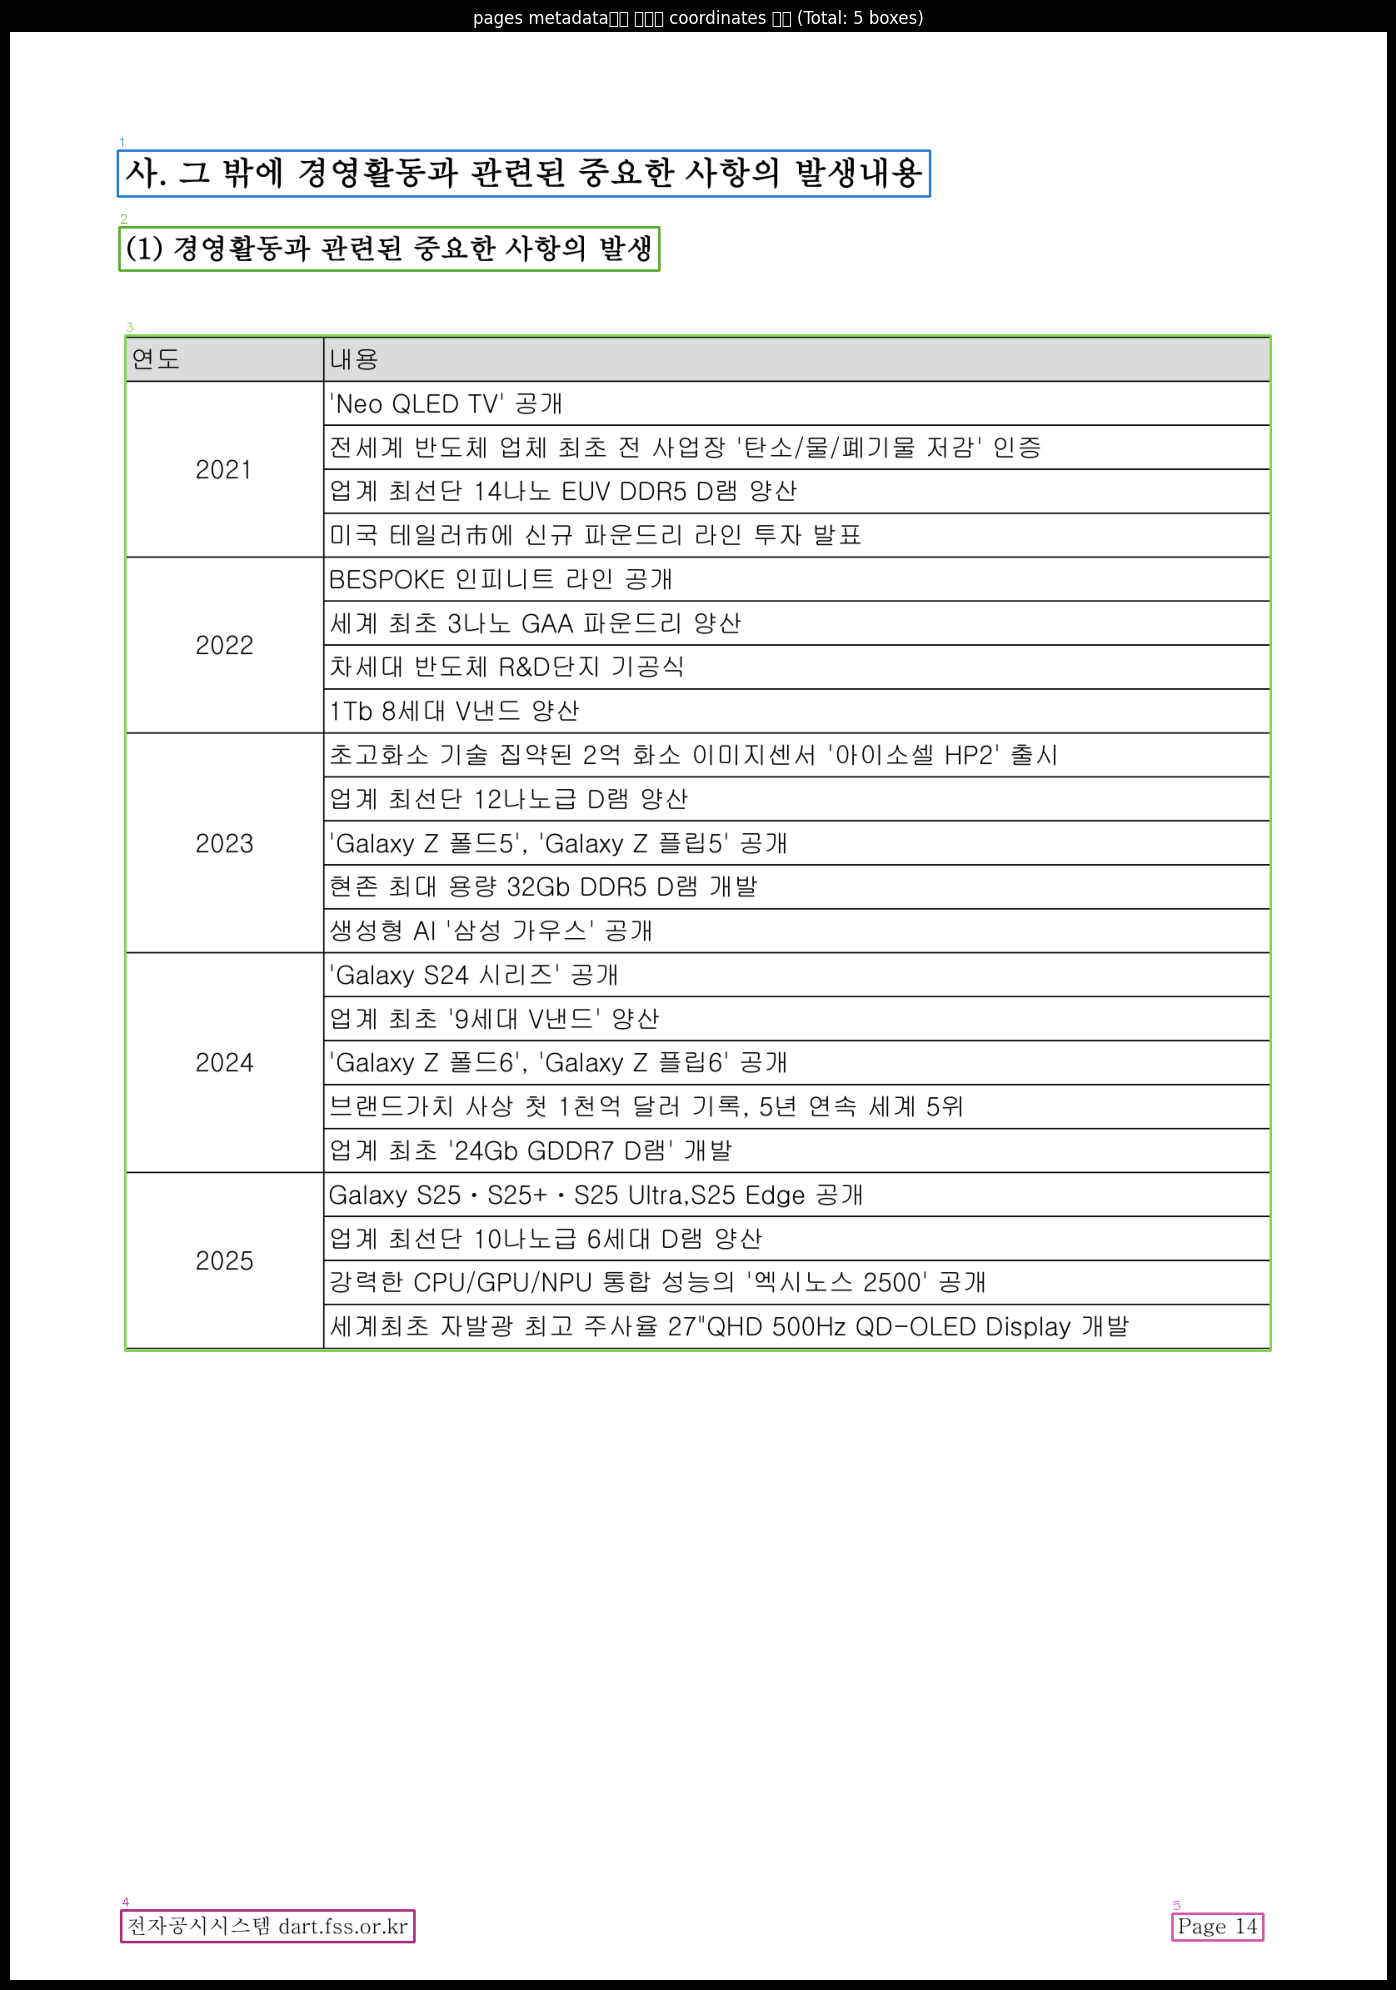

총 5개의 박스가 그려졌습니다.


In [16]:
# pages의 metadata에서 coordinates를 읽어와서 박스 그리기
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import json

# 변환된 PNG 이미지 경로
image_path = "./data/12.png"
print(image_path)


# pages에서 coordinates 데이터 추출
def extract_coordinates_from_pages(pages):
    """
    pages의 metadata에서 coordinates 데이터를 추출하는 함수

    Args:
        pages: UpstageDocumentParseLoader로 로드된 페이지 데이터

    Returns:
        list: coordinates 데이터 리스트
    """
    all_coordinates = []

    for page in pages:
        if hasattr(page, "metadata") and "coordinates" in page.metadata:
            coordinates = page.metadata["coordinates"]
            if coordinates:
                all_coordinates.extend(coordinates)

    return all_coordinates


try:
    # pages에서 coordinates 추출
    if "pages" in locals() and pages:
        coordinates_from_pages = extract_coordinates_from_pages(pages)

        if not coordinates_from_pages:
            print("pages의 metadata에서 coordinates를 찾을 수 없습니다.")
            print("metadata 구조 확인:")
            for i, page in enumerate(pages[:1]):  # 첫 번째 페이지만 출력
                print(f"Page {i+1} metadata keys: {list(page.metadata.keys())}")
        else:
            print(
                f"pages에서 {len(coordinates_from_pages)}개의 coordinates를 찾았습니다."
            )

            # 이미지 로드
            image = cv2.imread(image_path)
            if image is None:
                print(f"이미지를 찾을 수 없습니다: {image_path}")
            else:
                # 이미지 크기 가져오기
                height, width = image.shape[:2]
                print(f"이미지 크기: {width} x {height}")

                # BGR에서 RGB로 변환
                image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

                # 각 coordinates에 대해 박스 그리기
                for i, coord_group in enumerate(coordinates_from_pages):
                    # 색상 선택 (각 박스마다 다른 색상)
                    color = (
                        int(255 * ((i % 5) + 1) / 6),
                        int(255 * (((i + 2) % 5) + 1) / 6),
                        int(255 * (((i + 4) % 5) + 1) / 6),
                    )

                    # coordinates 데이터 처리
                    if isinstance(coord_group, list) and len(coord_group) >= 4:
                        # 첫 번째와 세 번째 점으로 사각형 그리기
                        if all("x" in coord and "y" in coord for coord in coord_group):
                            x1 = int(coord_group[0]["x"] * width)
                            y1 = int(coord_group[0]["y"] * height)
                            x2 = int(coord_group[2]["x"] * width)
                            y2 = int(coord_group[2]["y"] * height)

                            # 사각형 그리기
                            cv2.rectangle(image_rgb, (x1, y1), (x2, y2), color, 2)

                            # 박스 번호 표시
                            cv2.putText(
                                image_rgb,
                                str(i + 1),
                                (x1, y1 - 5),
                                cv2.FONT_HERSHEY_SIMPLEX,
                                0.5,
                                color,
                                1,
                            )

                # 결과 이미지 디스플레이
                plt.figure(figsize=(15, 20))
                plt.imshow(image_rgb)
                plt.title(
                    f"pages metadata에서 추출한 coordinates 박스 (Total: {len(coordinates_from_pages)} boxes)"
                )
                plt.axis("off")
                plt.tight_layout()
                plt.show()

                print(f"총 {len(coordinates_from_pages)}개의 박스가 그려졌습니다.")

    else:
        print(
            "pages 변수가 정의되지 않았습니다. 먼저 3번째 셀을 실행하여 pages를 로드해주세요."
        )

except Exception as e:
    print(f"오류 발생: {e}")
    import traceback

    traceback.print_exc()